<a href="https://colab.research.google.com/github/OrangeJeon/AI-based-Harmful-Algae-Detection/blob/master/AI_based_Harmful_Algae_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [5]:
#자료 파일로 만들기
import pandas as pd

file_path = "/content/(한국수자원공사)조류경보 예측 AI 모델 개발 데이터셋(지정과제) (1).xlsx"

def save_clean_csv(sheet_name, output_csv, header_keywords):
    raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    header_row = None
    for i, row in raw.iterrows():
        text = " ".join(row.dropna().astype(str))
        if any(keyword in text for keyword in header_keywords):
            header_row = i
            break

    if header_row is None:
        raise ValueError(f"{sheet_name}에서 컬럼명 행을 찾지 못했습니다.")

    df = pd.read_excel(file_path, sheet_name=sheet_name, header=header_row)

    df = df.dropna(how="all")
    df = df.dropna(axis=1, how="all")
    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]

    df.to_csv(output_csv, index=False, encoding="utf-8-sig")
    print(f"{output_csv} 저장 완료 / header row: {header_row}")

save_clean_csv(
    sheet_name="대청호 조류모니터링_일자료",
    output_csv="대청호_조류모니터링_일자료.csv",
    header_keywords=["조사일", "채수일", "측정일"]
)

save_clean_csv(
    sheet_name="대청댐 운영정보",
    output_csv="운영정보.csv",
    header_keywords=["일자", "년월일", "날짜", "수위", "유입량", "방류량"]
)

대청호_조류모니터링_일자료.csv 저장 완료 / header row: 2
운영정보.csv 저장 완료 / header row: 4


In [6]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv('/content/한국수자원공사_다목적댐 수질정보_20250921.csv', encoding='utf-8')

# 댐코드가 3008110인 행만 필터링
filtered_df = df[df['댐코드'] == 3008110]

# 결과 저장
filtered_df.to_csv('output.csv', index=False, encoding='utf-8-sig')

print(f"전체 {len(df)}행 중 {len(filtered_df)}행이 남았습니다.")
print(filtered_df)

전체 4538행 중 259행이 남았습니다.
          댐코드  댐명         측정월    수온  수소이온농도지수(pH)  용존산소(DO)  생물학적 산소요구량(BOD)  \
3     3008110  대청  2025-08-25  25.0           7.5       7.0              0.8   
23    3008110  대청  2025-07-25  25.0           7.5       7.8              1.7   
53    3008110  대청  2025-06-25  16.0           8.0       9.4              1.5   
74    3008110  대청  2025-05-25  16.0           7.6       9.7              1.5   
93    3008110  대청  2025-04-25  12.0           7.8      14.7              0.3   
...       ...  ..         ...   ...           ...       ...              ...   
4454  3008110  대청  2020-03-05   8.0           7.6      11.3              1.4   
4459  3008110  대청  2020-03-04   7.0           7.9      12.2              1.2   
4467  3008110  대청  2020-03-03   6.0           8.8      13.6              1.1   
4469  3008110  대청  2020-03-02   5.0           8.6      12.3              1.7   
4474  3008110  대청  2020-03-01   7.0           8.2      11.7              1.3   

      화학적 산소요구량

In [7]:
import pandas as pd

# 1. 댐 수질 데이터 로드 및 전처리
df_dam = pd.read_csv('/content/한국수자원공사_다목적댐 수질정보_20250921.csv', encoding='utf-8')

# 대청댐(3008110)만 필터링
df_dam = df_dam[df_dam['댐코드'] == 3008110].copy()

# 날짜 변환
df_dam['측정월'] = pd.to_datetime(df_dam['측정월'])

# 사용할 변수만 선택 + 컬럼명 정리
df_dam_use = df_dam[[
    '측정월',
    '총질소(T-N)',
    '총인(T-P)',
    '화학적 산소요구량(COD)',
    '전기전도도'
]].copy()
df_dam_use.columns = ['date', 'TN', 'TP', 'COD', 'EC']


# 2. 조류 데이터 로드 및 전처리
df_algae = pd.read_csv('/content/대청호_조류모니터링_일자료.csv', encoding='utf-8')

# 대청호 문의 지점만
df_algae = df_algae[
    (df_algae['지점명'] == '대청호') &
    (df_algae['채수위치'] == '문의')
].copy()

df_algae['조사일'] = pd.to_datetime(df_algae['조사일'])


# 3. 정확한 날짜 매칭 (inner join)

merged = pd.merge(
    df_algae,
    df_dam_use,
    left_on='조사일',
    right_on='date',
    how='inner'  # 양쪽 다 있는 날짜만 남김
)

# 중복 컬럼 제거
merged = merged.drop(columns=['date'])

# 4. 결과 확인
print(f"조류 데이터 전체 행: {len(df_algae)}")
print(f"댐 데이터 전체 행: {len(df_dam_use)}")
print(f"매칭된 행 수: {len(merged)}")

print(f"\n매칭된 날짜:")
print(merged['조사일'].dt.strftime('%Y-%m-%d').tolist())

print(f"\n병합 결과 미리보기:")
cols_to_show = [
    '조사일', '수온(℃)', 'pH', 'DO(㎎/L)',
    '유해남조류 \n세포수 (cells/㎖)\n(1+2+3+4)',
    'TN', 'TP', 'COD', 'EC'
]
print(merged[cols_to_show])

# 결과 저장
merged.to_csv('merged_exact.csv', index=False, encoding='utf-8-sig')
print("\n→ merged_exact.csv 저장 완료")

조류 데이터 전체 행: 542
댐 데이터 전체 행: 259
매칭된 행 수: 38

매칭된 날짜:
['2020-03-02', '2020-04-06', '2020-05-04', '2020-05-11', '2020-06-01', '2020-06-08', '2020-07-06', '2020-08-04', '2020-08-12', '2020-09-08', '2020-10-05', '2020-10-07', '2020-10-12', '2020-11-02', '2020-11-09', '2020-12-07', '2025-01-13', '2025-01-20', '2025-02-17', '2025-03-17', '2025-04-14', '2025-04-21', '2025-05-19', '2025-06-16', '2025-06-23', '2025-07-14', '2025-07-21', '2025-08-13', '2025-08-18', '2025-08-21', '2025-08-25', '2025-09-15', '2025-09-22', '2025-10-13', '2025-10-20', '2025-11-17', '2025-12-15', '2025-12-22']

병합 결과 미리보기:
          조사일  수온(℃)   pH  DO(㎎/L)  유해남조류 \n세포수 (cells/㎖)\n(1+2+3+4)     TN  \
0  2020-03-02    7.6  7.5     11.4                               0.0  2.251   
1  2020-04-06    9.3  7.8     10.7                               0.0  1.052   
2  2020-05-04   14.0  7.9     10.7                               0.0  1.205   
3  2020-05-11   14.5  7.9     10.2                               0.0  1.504   
4  20

In [8]:
import pandas as pd
import numpy as np

# 데이터 로드 (이전 코드와 동일)
df_dam = pd.read_csv('/content/한국수자원공사_다목적댐 수질정보_20250921.csv', encoding='utf-8')
df_dam = df_dam[df_dam['댐코드'] == 3008110].copy()
df_dam['측정월'] = pd.to_datetime(df_dam['측정월'])
df_dam_use = df_dam[['측정월', '총질소(T-N)', '총인(T-P)',
                      '화학적 산소요구량(COD)', '전기전도도']].copy()
df_dam_use.columns = ['date', 'TN', 'TP', 'COD', 'EC']
df_dam_use = df_dam_use.sort_values('date').reset_index(drop=True)

df_algae = pd.read_csv('/content/대청호_조류모니터링_일자료.csv', encoding='utf-8')
df_algae = df_algae[(df_algae['지점명'] == '대청호') &
                     (df_algae['채수위치'] == '문의')].copy()
df_algae['조사일'] = pd.to_datetime(df_algae['조사일'])
df_algae = df_algae.sort_values('조사일').reset_index(drop=True)

# ±N일 허용 매칭 비교
for tol_days in [0, 3, 7, 14, 30]:
    if tol_days == 0:
        merged = pd.merge(df_algae, df_dam_use,
                         left_on='조사일', right_on='date', how='inner')
    else:
        merged = pd.merge_asof(
            df_algae, df_dam_use,
            left_on='조사일', right_on='date',
            direction='nearest',
            tolerance=pd.Timedelta(days=tol_days)
        ).dropna(subset=['TN'])
    print(f"±{tol_days:>2}일: {len(merged)}행")

± 0일: 38행
± 3일: 63행
± 7일: 86행
±14일: 101행
±30일: 108행


In [9]:
# ±7일 허용으로 베이스 데이터 확보
TOL = 7
merged = pd.merge_asof(
    df_algae, df_dam_use,
    left_on='조사일', right_on='date',
    direction='nearest',
    tolerance=pd.Timedelta(days=TOL)
).dropna(subset=['TN']).reset_index(drop=True)

# A. 시간 관련 피처
merged['month'] = merged['조사일'].dt.month
merged['doy'] = merged['조사일'].dt.dayofyear
# 주기성 인코딩 (12월과 1월이 가깝다는 걸 모델이 알 수 있게)
merged['month_sin'] = np.sin(2 * np.pi * merged['month'] / 12)
merged['month_cos'] = np.cos(2 * np.pi * merged['month'] / 12)
merged['is_summer'] = merged['month'].isin([6, 7, 8, 9]).astype(int)

# B. 누적 강수량/일조 (조류 발생에 직접 영향)
merged['일강수량(mm)'] = merged['일강수량(mm)'].fillna(0)
merged['rain_3w'] = merged['일강수량(mm)'].rolling(3, min_periods=1).sum()
merged['rain_5w'] = merged['일강수량(mm)'].rolling(5, min_periods=1).sum()
merged['sun_3w'] = merged['일조시간 합계(hr)'].rolling(3, min_periods=1).mean()

# C. 영양염 비율/조합 (생태학적으로 의미 있음)
merged['TN_TP_ratio'] = merged['TN'] / merged['TP']  # N:P 비
merged['TP_log'] = np.log1p(merged['TP'])  # TP는 log 분포
merged['TN_log'] = np.log1p(merged['TN'])

# D. 조류 자체의 시계열 피처 (가장 강력한 예측 변수)
target_col = '유해남조류 \n세포수 (cells/㎖)\n(1+2+3+4)'
merged[target_col] = merged[target_col].fillna(0)

# 1주 전, 2주 전 세포수 (자기상관)
merged['cells_lag1'] = merged[target_col].shift(1)
merged['cells_lag2'] = merged[target_col].shift(2)
merged['cells_log_lag1'] = np.log1p(merged['cells_lag1'])

# 최근 3주 평균/최댓값
merged['cells_ma3'] = merged[target_col].shift(1).rolling(3, min_periods=1).mean()
merged['cells_max3'] = merged[target_col].shift(1).rolling(3, min_periods=1).max()

# E. 수온 변화량 (수온 급상승 시 조류 폭증)
merged['수온_diff'] = merged['수온(℃)'].diff()
merged['수온_ma3'] = merged['수온(℃)'].rolling(3, min_periods=1).mean()

# 결과 확인
feature_cols = ['수온(℃)', 'pH', 'DO(㎎/L)', '탁도',
                'TN', 'TP', 'COD', 'EC',
                'month_sin', 'month_cos', 'is_summer',
                'rain_3w', 'rain_5w', 'sun_3w',
                'TN_TP_ratio', 'TP_log', 'TN_log',
                'cells_lag1', 'cells_log_lag1', 'cells_ma3', 'cells_max3',
                '수온_diff', '수온_ma3']

print(f"최종 행 수: {len(merged)}")
print(f"피처 수: {len(feature_cols)}")
print(f"\n결측치 현황:")
print(merged[feature_cols].isna().sum()[merged[feature_cols].isna().sum() > 0])

merged.to_csv('merged_with_features.csv', index=False, encoding='utf-8-sig')

최종 행 수: 86
피처 수: 23

결측치 현황:
수온(℃)             1
pH                1
DO(㎎/L)           1
탁도                1
cells_lag1        1
cells_log_lag1    1
cells_ma3         1
cells_max3        1
수온_diff           3
dtype: int64


In [10]:
!apt-get update -qq
!apt-get install -y fonts-nanum
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 17 not upgraded.


In [11]:
import subprocess, os, glob

# 1) 나눔고딕 패키지 설치
subprocess.run(['apt-get', 'install', '-y', '-qq', 'fonts-nanum'], check=True)
print("fonts-nanum 설치 완료")

# 2) matplotlib 폰트 캐시 전체 삭제 (새 폰트 인식을 위해 필수)
import matplotlib
cache_dir = matplotlib.get_cachedir()
for f in glob.glob(os.path.join(cache_dir, 'font*')):
    os.remove(f)
print(f"폰트 캐시 삭제: {cache_dir}")

# 3) 설치 확인
result = subprocess.run(['fc-list', ':lang=ko', '--format=%{family}\n'],
                        capture_output=True, text=True)
nanum_fonts = [l for l in result.stdout.splitlines() if 'Nanum' in l]
print(f"설치된 나눔 폰트: {nanum_fonts[:3]}")
print("\n 여기까지 실행 후 [런타임 → 런타임 다시 시작] 하세요!")
print("   재시작 후 이 셀은 건너뛰고 아래 셀부터 실행하면 됩니다.")

fonts-nanum 설치 완료
폰트 캐시 삭제: /root/.cache/matplotlib
설치된 나눔 폰트: ['NanumGothic,나눔고딕', 'NanumMyeongjo,나눔명조', 'NanumSquare,나눔스퀘어,NanumSquare Bold,나눔스퀘어 Bold']

 여기까지 실행 후 [런타임 → 런타임 다시 시작] 하세요!
   재시작 후 이 셀은 건너뛰고 아래 셀부터 실행하면 됩니다.


In [12]:
import subprocess, glob, os
import matplotlib as mpl
import matplotlib.font_manager as fm

subprocess.run(['apt-get', 'install', '-y', '-qq', 'fonts-nanum'], check=True)

# 캐시 무시하고 강제 재스캔
fm._load_fontmanager(try_read_cache=False)

nanum_files = glob.glob('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
if nanum_files:
    _fp   = fm.FontProperties(fname=nanum_files[0])
    _name = _fp.get_name()
    mpl.rcParams['font.family']        = _name
    mpl.rcParams['axes.unicode_minus'] = False
    print(f"한글 폰트 적용: '{_name}'")
else:
    print("NanumGothic.ttf 없음 — apt-get install fonts-nanum 확인")

한글 폰트 적용: 'NanumGothic'


In [13]:
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns

# 설치된 나눔 폰트 파일 확인
font_paths = glob.glob("/usr/share/fonts/truetype/nanum/*.ttf")
print(font_paths)

# 파일 경로 직접 지정
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid", font=font_name)

print("적용된 폰트:", font_name)

['/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareR.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf']
적용된 폰트: NanumGothic


In [14]:
# ── 라이브러리 ────────────────────────────────────────────────────────────────
import warnings, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.preprocessing          import MinMaxScaler
from sklearn.model_selection        import StratifiedKFold, GridSearchCV
from sklearn.metrics                import (accuracy_score, confusion_matrix,
                                            classification_report)
from imblearn.over_sampling         import RandomOverSampler
from xgboost                        import XGBClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = '/mnt/user-data/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [15]:
MONITORING_PATH = '/content/대청호_조류모니터링_일자료.csv'
DAM_OPS_PATH = '/content/운영정보.csv'

In [16]:
# 1. 데이터 로드 및 전처리
print("\n" + "="*60)
print("1. 데이터 로드")
print("="*60)

df_mon = pd.read_csv(MONITORING_PATH, encoding='utf-8-sig')
df_dam = pd.read_csv(DAM_OPS_PATH,    encoding='utf-8-sig')


1. 데이터 로드


In [17]:
df = df_mon[df_mon['채수위치'] == '추동'].copy().reset_index(drop=True)

In [18]:
HA_COL = '유해남조류 \n세포수 (cells/㎖)\n(1+2+3+4)'
df = df.rename(columns={
    '조사일'          : 'Date',
    '일조시간 합계(hr)' : 'Duration_of_Sunshine',
    '수온(℃)'         : 'WT',
    'pH'              : 'pH',
    'DO(㎎/L)'        : 'DO',
    '투명도'          : 'Transparency',
    '탁도'            : 'Turb',
    'Chl-a (㎎/㎥)'  : 'Chl_a',
    '발령단계'        : 'Alert_Level',
    HA_COL            : 'HA_Cells',
})
df['Date'] = pd.to_datetime(df['Date'])

In [19]:
df_dam = df_dam.rename(columns={
    '일시'          : 'Date',
    '저수율(%)'     : 'Vol',
    '강우량(mm)'    : 'Rain_dam',
    '총방류량(㎥/s)': 'Total_Discharge',
})
df_dam['Date'] = pd.to_datetime(df_dam['Date'])

In [20]:
rain_7d = []
for date in df['Date']:
    mask = (df_dam['Date'] >= date - pd.Timedelta(days=6)) & \
           (df_dam['Date'] <= date)
    rain_7d.append(df_dam.loc[mask, 'Rain_dam'].sum())
df['Rain'] = rain_7d

In [21]:
# 2. 조류경보 타겟 라벨링 (HA_Cells 기반)
print("\n" + "="*60)
print("2. 타겟 라벨링 (HA_Cells 기반)")
print("="*60)

df['target'] = 0
df.loc[df['HA_Cells'] >= 1_000,     'target'] = 1   # 관심
df.loc[df['HA_Cells'] >= 10_000,    'target'] = 2   # 경계
df.loc[df['HA_Cells'] >= 1_000_000, 'target'] = 3   # 대발생

print("  target 분포 (전체):")
for k, v in df['target'].value_counts().sort_index().items():
    lbl = {0:'미발령', 1:'관심', 2:'경계', 3:'대발생'}[k]
    print(f"    {k} ({lbl}): {v}건")


2. 타겟 라벨링 (HA_Cells 기반)
  target 분포 (전체):
    0 (미발령): 413건
    1 (관심): 91건
    2 (경계): 32건


In [22]:
KEY_COLS = ['WT', 'DO', 'Chl_a', 'Transparency', 'Turb',
            'Rain', 'HA_Cells']
df = df.dropna(subset=KEY_COLS).reset_index(drop=True)
print(f"\n  결측 제거 후: {df.shape[0]}행")
print("  target 분포 (결측 제거 후):")
for k, v in df['target'].value_counts().sort_index().items():
    lbl = {0:'미발령', 1:'관심', 2:'경계', 3:'대발생'}[k]
    print(f"    {k} ({lbl}): {v}건")



  결측 제거 후: 515행
  target 분포 (결측 제거 후):
    0 (미발령): 392건
    1 (관심): 91건
    2 (경계): 32건


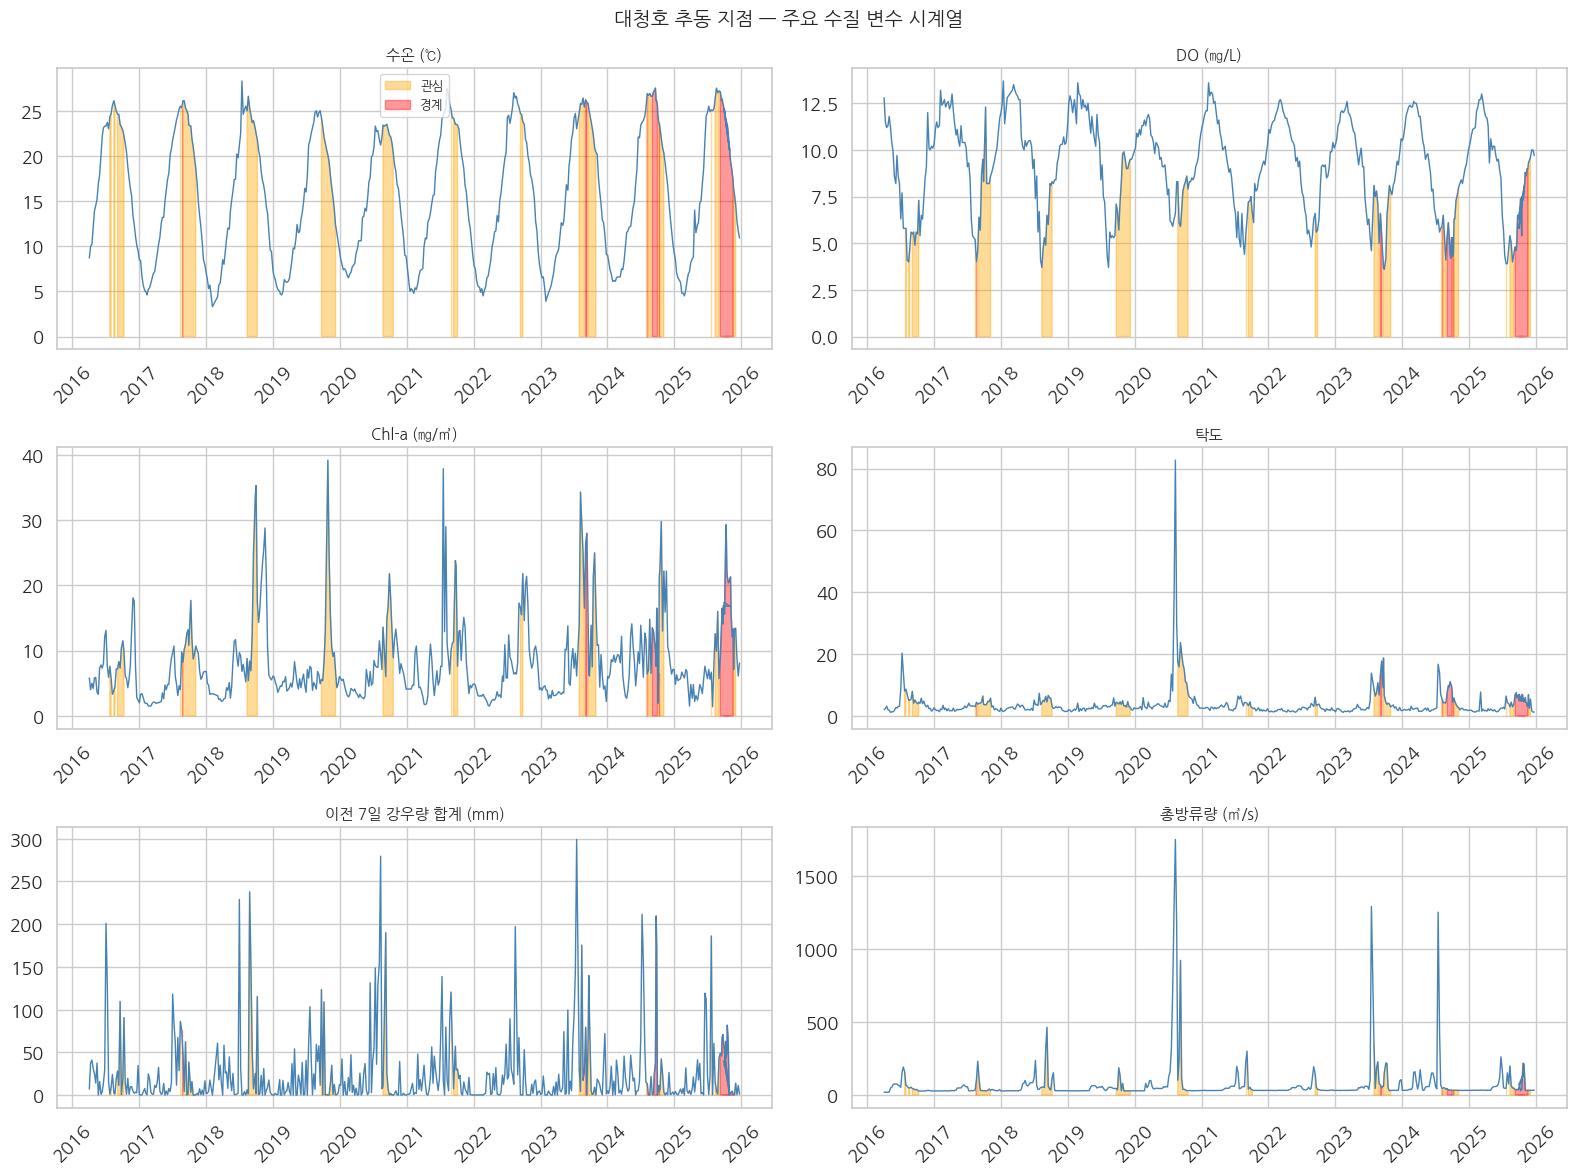

In [23]:
# 3. 시계열 탐색적 시각화
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# ★ 그래프 직전에 폰트 강제 적용
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)
print("="*60)

target_colors = {0:'green', 1:'orange', 2:'red', 3:'purple'}

# Calculate 7-day average of Total_Discharge and add it to df
# This part is added to resolve KeyError: 'Total_Discharge'
total_discharge_7d_avg = []
for date in df['Date']:
    # Consider 7 days *prior* to the current date, consistent with the original notebook's df_dam_agg logic
    window = df_dam[(df_dam['Date'] >= date - pd.Timedelta(days=7)) &
                    (df_dam['Date'] <  date)]
    if not window.empty:
        total_discharge_7d_avg.append(window['Total_Discharge'].mean())
    else:
        total_discharge_7d_avg.append(np.nan) # Append NaN if no data in window

df_temp = df.copy() # Create a temporary copy to avoid SettingWithCopyWarning
df_temp['Total_Discharge'] = total_discharge_7d_avg
# Fill NaNs that might occur at the beginning of the series due to the window
df_temp['Total_Discharge'] = df_temp['Total_Discharge'].fillna(method='ffill').fillna(method='bfill')
df = df_temp # Update the df to the modified one

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('대청호 추동 지점 — 주요 수질 변수 시계열', fontsize=14, fontweight='bold')

plot_vars = [
    ('WT',         '수온 (℃)'),
    ('DO',         'DO (㎎/L)'),
    ('Chl_a',      'Chl-a (㎎/㎥)'),
    ('Turb',       '탁도'),
    ('Rain',       '이전 7일 강우량 합계 (mm)'),
    ('Total_Discharge', '총방류량 (㎥/s)'),
]
for ax, (col, label) in zip(axes.flat, plot_vars):
    ax.plot(df['Date'], df[col], color='steelblue', lw=1)
    ax.fill_between(df['Date'], df[col],
                    where=(df['target'] == 1), color='orange', alpha=0.4, label='관심')
    ax.fill_between(df['Date'], df[col],
                    where=(df['target'] == 2), color='red',    alpha=0.4, label='경계')
    ax.set_title(label, fontsize=11)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    if col == 'WT':
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
plt.savefig(f'{OUTPUT_DIR}/01_timeseries.png', dpi=150, bbox_inches='tight')
plt.close()

In [24]:
# 4. 이상치 확인 및 처리 (IQR)
print("\n" + "="*60)
print("4. 이상치 처리 (IQR)")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('이상치 처리 전 박스플롯', fontsize=12)
for ax, col in zip(axes, ['Turb', 'Chl_a', 'Total_Discharge']):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_outlier_before.png', dpi=150, bbox_inches='tight')
plt.close()

# Turb: target=0인 이상치만 upper_bound로 대체 (ipynb 동일)
Q1_t, Q3_t = df['Turb'].quantile([0.25, 0.75])
IQR_t = Q3_t - Q1_t
upper_t = Q3_t + 1.5 * IQR_t
print(f"  Turb  — Q1:{Q1_t:.2f}, Q3:{Q3_t:.2f}, IQR:{IQR_t:.2f}, 상한:{upper_t:.2f}")
n_replaced = ((df['Turb'] > upper_t) & (df['target'] == 0)).sum()
df.loc[(df['Turb'] > upper_t) & (df['target'] == 0), 'Turb'] = upper_t
print(f"  Turb 이상치 대체 (target=0): {n_replaced}건")

# Chl_a: 이상치를 평균값으로 대체 (ipynb 동일)
Q1_c, Q3_c = df['Chl_a'].quantile([0.25, 0.75])
IQR_c = Q3_c - Q1_c
upper_c = Q3_c + 1.5 * IQR_c
print(f"  Chl_a — Q1:{Q1_c:.2f}, Q3:{Q3_c:.2f}, IQR:{IQR_c:.2f}, 상한:{upper_c:.2f}")
outlier_idx_c = df[df['Chl_a'] > upper_c].index
if len(outlier_idx_c):
    mean_c = df.loc[outlier_idx_c, 'Chl_a'].mean()
    df.loc[outlier_idx_c, 'Chl_a'] = mean_c
    print(f"  Chl_a 이상치 평균대체: {len(outlier_idx_c)}건 → 평균값 {mean_c:.2f}")


4. 이상치 처리 (IQR)
  Turb  — Q1:1.90, Q3:4.10, IQR:2.20, 상한:7.40
  Turb 이상치 대체 (target=0): 12건
  Chl_a — Q1:4.30, Q3:10.50, IQR:6.20, 상한:19.80
  Chl_a 이상치 평균대체: 39건 → 평균값 25.47


In [25]:
# 5. 파생 변수 생성: Turb_Transparency
print("="*60)
df['Turb_Transparency'] = df['Turb'] - df['Transparency']
print("  Turb_Transparency = Turb - Transparency 생성 완료")

# ── HA_Cells 컬럼 제거 ─────────────────────────────────────────────────────
df_clean = df.drop(columns=['HA_Cells'], errors='ignore')

  Turb_Transparency = Turb - Transparency 생성 완료


In [26]:
# 6. 이진 타겟 생성 + Min-Max 정규화
print("="*60)

# 이진 분류 (0=미발령, 1=관심+경계+대발생)
df_clean['newlabel'] = df_clean['target'].replace({0:0, 1:1, 2:1, 3:1})
print("  이진 레이블 분포:")
print("   ", df_clean['newlabel'].value_counts().to_dict())

# 정규화 대상 컬럼
NORM_COLS = ['WT', 'pH', 'DO', 'Transparency', 'Turb', 'Chl_a',
             'Vol', 'Rain', 'Total_Discharge', 'Duration_of_Sunshine',
             'Turb_Transparency']
NORM_COLS = [c for c in NORM_COLS if c in df_clean.columns]

scaler  = MinMaxScaler()
df_norm = df_clean.copy()
df_norm[NORM_COLS] = scaler.fit_transform(df_clean[NORM_COLS])
print(f"  정규화 완료: {NORM_COLS}")

  이진 레이블 분포:
    {0: 392, 1: 123}
  정규화 완료: ['WT', 'pH', 'DO', 'Transparency', 'Turb', 'Chl_a', 'Rain', 'Total_Discharge', 'Duration_of_Sunshine', 'Turb_Transparency']


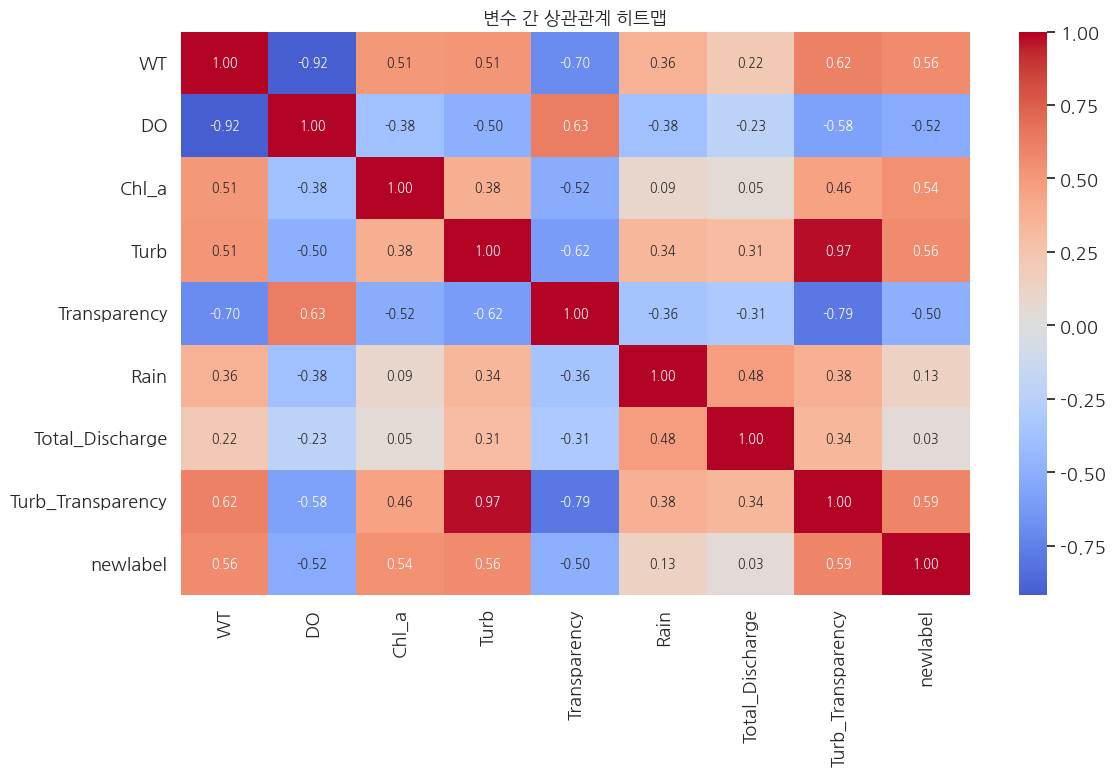

In [27]:
# 7. 히트맵 (상관관계)
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# ★ 그래프 직전에 폰트 강제 적용
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

print("="*60)

NUMERIC_COLS = ['WT', 'DO', 'Chl_a', 'Turb', 'Transparency',
                'Rain', 'Total_Discharge', 'Vol', 'Turb_Transparency', 'newlabel']
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in df_norm.columns]

plt.figure(figsize=(12, 8))
corr = df_norm[NUMERIC_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 9})
plt.title('변수 간 상관관계 히트맵', fontsize=13)
plt.tight_layout()
plt.show()
plt.savefig(f'{OUTPUT_DIR}/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()

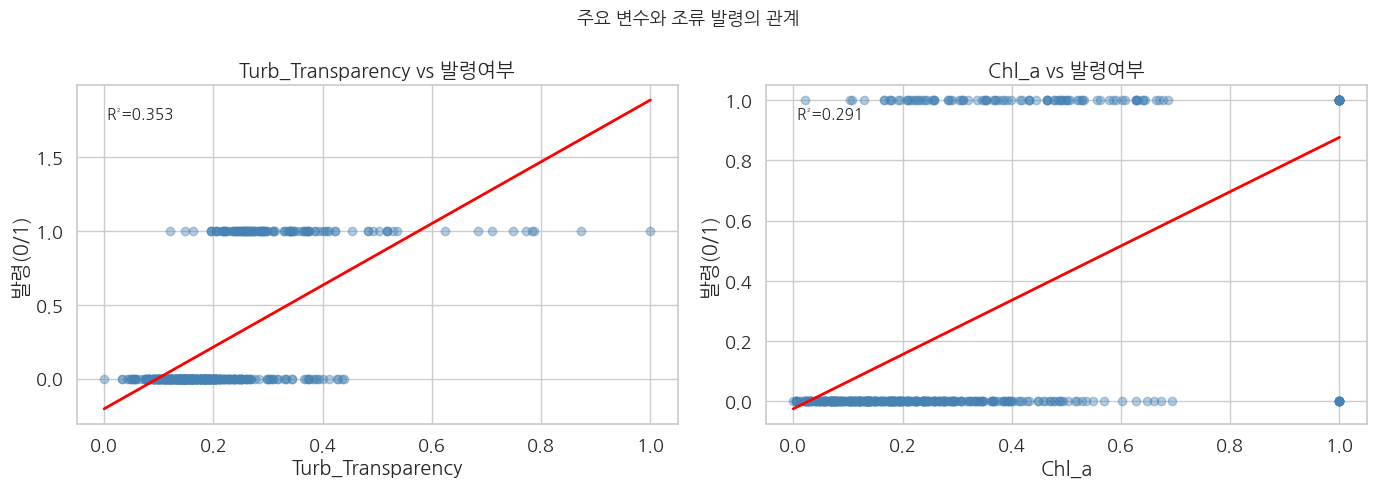

In [28]:
# 8. 산점도 — Turb_Transparency vs newlabel
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# ★ 그래프 직전에 폰트 강제 적용
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('주요 변수와 조류 발령의 관계', fontsize=13)

for ax, col in zip(axes, ['Turb_Transparency', 'Chl_a']):
    ax.scatter(df_norm[col], df_norm['newlabel'], alpha=0.4, color='steelblue')
    X_r = df_norm[[col]].values
    y_r = df_norm['newlabel'].values
    reg = LinearRegression().fit(X_r, y_r)
    ax.plot(sorted(X_r), reg.predict(sorted(X_r)), color='red', lw=2)
    r2 = reg.score(X_r, y_r)
    ax.text(0.05, 0.9, f'R²={r2:.3f}', transform=ax.transAxes, fontsize=11)
    ax.set_xlabel(col); ax.set_ylabel('발령(0/1)')
    ax.set_title(f'{col} vs 발령여부')

plt.tight_layout()
plt.show()
plt.savefig(f'{OUTPUT_DIR}/04_scatter.png', dpi=150, bbox_inches='tight')
plt.close()

In [29]:
# 9. VIF (다중공선성) 확인
print("="*60)

FEATURE_COLS = ['WT', 'DO', 'Chl_a', 'Rain', 'Total_Discharge', 'Turb_Transparency']

vif_data = df_norm[FEATURE_COLS].values
vif_df   = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'VIF Factor' : [variance_inflation_factor(vif_data, i)
                    for i in range(vif_data.shape[1])]
})
print(vif_df.to_string(index=False))

          Feature  VIF Factor
               WT    6.769795
               DO    1.858826
            Chl_a    3.389194
             Rain    1.990391
  Total_Discharge    1.541350
Turb_Transparency    7.478591


In [30]:
#lag 피처 + 계절성 (과적합 완화 + 정확도 ↑)
print("\n" + "="*60)
print("[추가] lag 피처 + 계절성")
print("="*60)

df_norm = df_norm.sort_values('Date').reset_index(drop=True)

#(a) lag 피처
for lag in [1, 2]:
    df_norm[f'Chl_a_lag{lag}']    = df_norm['Chl_a'].shift(lag)
    df_norm[f'WT_lag{lag}']       = df_norm['WT'].shift(lag)
    df_norm[f'newlabel_lag{lag}'] = df_norm['newlabel'].shift(lag)
    df_norm[f'Turb_T_lag{lag}']   = df_norm['Turb_Transparency'].shift(lag)

#(b) 이동평균/추세
df_norm['Chl_a_ma3']  = df_norm['Chl_a'].rolling(3, min_periods=1).mean()
df_norm['Chl_a_diff'] = df_norm['Chl_a'].diff().fillna(0)
df_norm['WT_diff']    = df_norm['WT'].diff().fillna(0)

#(c) 계절성
df_norm['month']     = df_norm['Date'].dt.month
df_norm['month_sin'] = np.sin(2*np.pi*df_norm['month']/12)
df_norm['month_cos'] = np.cos(2*np.pi*df_norm['month']/12)

#(d) 누적 환경
df_norm['Rain_ma4'] = df_norm['Rain'].rolling(4, min_periods=1).sum()
df_norm['Sun_ma3']  = df_norm['Duration_of_Sunshine'].rolling(3, min_periods=1).mean()

#결측 처리 (첫 2주만)
df_norm = df_norm.fillna(method='bfill').fillna(0)

print(f"피처 추가 완료. df_norm shape: {df_norm.shape}")


[추가] lag 피처 + 계절성
피처 추가 완료. df_norm shape: (515, 38)


In [31]:

# [9.5번 셀] 대청댐 수질정보 병합 + lag 피처 + 계절성 추가
# 10번 셀 실행 전 반드시 먼저 실행할 것!
print("\n" + "="*60)
print("[9.5] 댐 수질 + lag 피처 + 계절성 추가")
print("="*60)

# (1) 대청댐 수질정보(TN/TP/COD/EC) 병합
DAM_WQ_PATH = '/content/한국수자원공사_다목적댐 수질정보_20250921.csv'
df_dam_wq = pd.read_csv(DAM_WQ_PATH, encoding='utf-8')
df_dam_wq = df_dam_wq[df_dam_wq['댐코드'] == 3008110].copy()
df_dam_wq['측정월'] = pd.to_datetime(df_dam_wq['측정월'])

df_dam_wq_use = df_dam_wq[[
    '측정월', '총질소(T-N)', '총인(T-P)',
    '화학적 산소요구량(COD)', '전기전도도'
]].copy()
df_dam_wq_use.columns = ['Date', 'TN', 'TP', 'COD', 'EC']
df_dam_wq_use = df_dam_wq_use.sort_values('Date').reset_index(drop=True)

df_norm = df_norm.sort_values('Date').reset_index(drop=True)
df_norm = pd.merge_asof(
    df_norm, df_dam_wq_use,
    on='Date', direction='backward'
)

# 첫 댐 측정일 이전의 결측은 backfill + 평균
for c in ['TN', 'TP', 'COD', 'EC']:
    df_norm[c] = df_norm[c].fillna(method='bfill')
    df_norm[c] = df_norm[c].fillna(df_norm[c].mean())

# 새 피처 정규화
new_scaler = MinMaxScaler()
df_norm[['TN', 'TP', 'COD', 'EC']] = new_scaler.fit_transform(
    df_norm[['TN', 'TP', 'COD', 'EC']]
)
print("댐 수질(TN/TP/COD/EC) 4개 추가")

# (2) lag 피처 (자기상관)
for lag in [1, 2]:
    df_norm[f'Chl_a_lag{lag}']    = df_norm['Chl_a'].shift(lag)
    df_norm[f'WT_lag{lag}']       = df_norm['WT'].shift(lag)
    df_norm[f'newlabel_lag{lag}'] = df_norm['newlabel'].shift(lag)
    df_norm[f'Turb_T_lag{lag}']   = df_norm['Turb_Transparency'].shift(lag)
print("lag 피처 8개 추가")

# (3) 이동평균/추세
df_norm['Chl_a_ma3']  = df_norm['Chl_a'].rolling(3, min_periods=1).mean()
df_norm['Chl_a_diff'] = df_norm['Chl_a'].diff().fillna(0)
df_norm['WT_diff']    = df_norm['WT'].diff().fillna(0)
print("추세 피처 3개 추가")

# (4) 계절성 (sin/cos 인코딩)
df_norm['month']     = df_norm['Date'].dt.month
df_norm['month_sin'] = np.sin(2*np.pi*df_norm['month']/12)
df_norm['month_cos'] = np.cos(2*np.pi*df_norm['month']/12)
print("계절성 피처 2개 추가")

# (5) 누적 환경
df_norm['Rain_ma4'] = df_norm['Rain'].rolling(4, min_periods=1).sum()
df_norm['Sun_ma3']  = df_norm['Duration_of_Sunshine'].rolling(3, min_periods=1).mean()
print("누적 환경 피처 2개 추가")

# (6) 결측 처리
df_norm = df_norm.fillna(method='bfill').fillna(0)

print(f"\n  최종 df_norm: {df_norm.shape[0]}행 × {df_norm.shape[1]}컬럼")
print(f"  TN/TP/COD/EC 포함 확인: {all(c in df_norm.columns for c in ['TN','TP','COD','EC'])}")


[9.5] 댐 수질 + lag 피처 + 계절성 추가
댐 수질(TN/TP/COD/EC) 4개 추가
lag 피처 8개 추가
추세 피처 3개 추가
계절성 피처 2개 추가
누적 환경 피처 2개 추가

  최종 df_norm: 515행 × 42컬럼
  TN/TP/COD/EC 포함 확인: True


In [32]:
import pandas as pd

# 10. Train / Test 분리 (시계열 → 마지막 20% holdout)
print("\n" + "="*60)
print("10. Train / Test 분리 (확장 피처)")
print("="*60)

FEATURE_COLS = [
    # 원본 6개
    'WT', 'DO', 'Chl_a', 'Rain', 'Total_Discharge', 'Turb_Transparency',
    # 댐 수질 4개
    'TN', 'TP', 'COD', 'EC',
    # lag
    'Chl_a_lag1', 'Chl_a_lag2',
    'newlabel_lag1', 'newlabel_lag2',
    'WT_lag1', 'Turb_T_lag1',
    # 추세/이동평균
    'Chl_a_ma3', 'Chl_a_diff', 'WT_diff',
    # 계절성
    'month_sin', 'month_cos',
    # 누적 환경
    'Rain_ma4', 'Sun_ma3',
]

X_data = df_norm[FEATURE_COLS].copy()
y_data = df_norm['newlabel'].shift(-1).copy()

X_data = X_data.iloc[:-1]
y_data = y_data.iloc[:-1]
dates_data = df_norm['Date'].iloc[:-1]

split_idx   = int(len(X_data) * 0.8)
X_train_raw = X_data.iloc[:split_idx]
X_test      = X_data.iloc[split_idx:]
y_train_raw = y_data.iloc[:split_idx]
y_test      = y_data.iloc[split_idx:]

train_dates = dates_data.iloc[:split_idx]
test_dates  = dates_data.iloc[split_idx:]

print(f"  Train: {X_train_raw.shape[0]}행  ({train_dates.min().date()} ~ {train_dates.max().date()})")
print(f"  Test : {X_test.shape[0]}행   ({test_dates.min().date()} ~ {test_dates.max().date()})")
print(f"  피처({len(FEATURE_COLS)}개): {FEATURE_COLS}")


10. Train / Test 분리 (확장 피처)
  Train: 411행  (2016-04-04 ~ 2024-03-25)
  Test : 103행   (2024-04-01 ~ 2025-12-15)
  피처(23개): ['WT', 'DO', 'Chl_a', 'Rain', 'Total_Discharge', 'Turb_Transparency', 'TN', 'TP', 'COD', 'EC', 'Chl_a_lag1', 'Chl_a_lag2', 'newlabel_lag1', 'newlabel_lag2', 'WT_lag1', 'Turb_T_lag1', 'Chl_a_ma3', 'Chl_a_diff', 'WT_diff', 'month_sin', 'month_cos', 'Rain_ma4', 'Sun_ma3']


In [33]:
# 11. StratifiedKFold → 마지막 fold train 사용 → RandomOverSampler
print("\n" + "="*60)
print("11. StratifiedKFold + RandomOverSampler")
print("="*60)

NUM_FOLDS = 5
stratkf   = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

X_train_fold = y_train_fold = None
for train_idx, val_idx in stratkf.split(X_train_raw, y_train_raw):
    X_train_fold = X_train_raw.iloc[train_idx]
    y_train_fold = y_train_raw.iloc[train_idx]

rus = RandomOverSampler(random_state=SEED)
X_resampled, y_resampled = rus.fit_resample(X_train_fold, y_train_fold)
print(f"  오버샘플링 전 클래스: {y_train_fold.value_counts().to_dict()}")
print(f"  오버샘플링 후 클래스: {pd.Series(y_resampled).value_counts().to_dict()}")



11. StratifiedKFold + RandomOverSampler
  오버샘플링 전 클래스: {0.0: 268, 1.0: 61}
  오버샘플링 후 클래스: {0.0: 268, 1.0: 268}


In [34]:
# 12. XGBClassifier + GridSearchCV
print("\n" + "="*60)
print("12. XGBClassifier + GridSearchCV")
print("="*60)

xgb_clf = XGBClassifier(random_state=SEED, eval_metric='logloss',
                        use_label_encoder=False)

param_grid = {
    'learning_rate'   : [0.05, 0.1],   # 0.3 제거 (과적합 방지)
    'max_depth'       : [3, 4],         # 5 제거 (얕게 유지)
    'min_child_weight': [1, 3, 5],
    'subsample'       : [0.7, 0.8],     # 1.0 제거
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha'       : [0, 0.1],       # L1 정규화 추가
    'n_estimators'    : [200, 400],
}

grid_search = GridSearchCV(
    estimator  = xgb_clf,
    param_grid = param_grid,
    scoring    = 'accuracy',
    cv         = stratkf,
    verbose    = 1,
    n_jobs     = -1,
)
grid_search.fit(X_resampled, y_resampled)

best_model = grid_search.best_estimator_
print(f"\n  최적 하이퍼파라미터: {grid_search.best_params_}")
print(f"  교차검증 최고 정확도: {grid_search.best_score_:.4f}")


12. XGBClassifier + GridSearchCV
Fitting 5 folds for each of 192 candidates, totalling 960 fits

  최적 하이퍼파라미터: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0, 'subsample': 0.8}
  교차검증 최고 정확도: 0.9739


In [35]:
#13. 테스트 평가
y_pred   = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n  ▶ 테스트 정확도: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  ▶ CV-Test 갭:   {grid_search.best_score_ - accuracy:+.4f}")
print("\n  분류 보고서:")
print(classification_report(y_test, y_pred,
                             target_names=['미발령(0)', '발령(1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("  Confusion Matrix:")
print(f"    실제\\예측    미발령  발령")
print(f"    미발령({cm[0].sum():3d}):    {cm[0,0]:3d}    {cm[0,1]:3d}")
print(f"    발령  ({cm[1].sum():3d}):    {cm[1,0]:3d}    {cm[1,1]:3d}")


  ▶ 테스트 정확도: 0.9320 (93.20%)
  ▶ CV-Test 갭:   +0.0419

  분류 보고서:
              precision    recall  f1-score   support

      미발령(0)       0.90      0.98      0.94        56
       발령(1)       0.98      0.87      0.92        47

    accuracy                           0.93       103
   macro avg       0.94      0.93      0.93       103
weighted avg       0.94      0.93      0.93       103

  Confusion Matrix:
    실제\예측    미발령  발령
    미발령( 56):     55      1
    발령  ( 47):      6     41


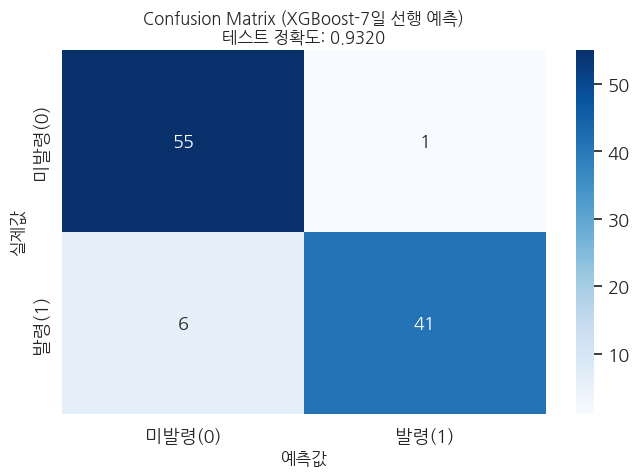

In [36]:
# 14. Confusion Matrix 시각화
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# ★ 그래프 직전에 폰트 강제 적용
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['미발령(0)', '발령(1)'],
            yticklabels=['미발령(0)', '발령(1)'],
            annot_kws={'size': 13})
plt.xlabel('예측값', fontsize=12)
plt.ylabel('실제값', fontsize=12)
plt.title(f'Confusion Matrix (XGBoost-7일 선행 예측)\n테스트 정확도: {accuracy:.4f}',
          fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig(f'{OUTPUT_DIR}/05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.close()

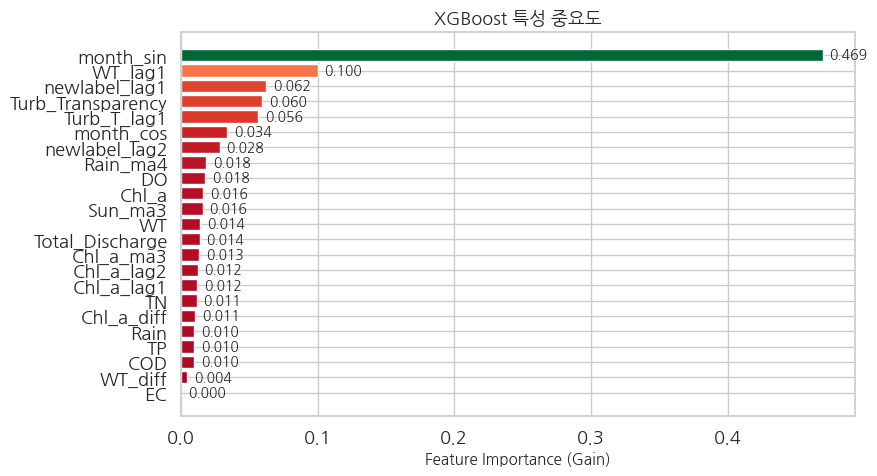

In [37]:
# 15. Feature Importance 시각화
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# ★ 그래프 직전에 폰트 강제 적용
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

fi = best_model.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': fi}) \
          .sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(fi_df['Feature'], fi_df['Importance'],
                color=plt.cm.RdYlGn(fi_df['Importance'] / fi_df['Importance'].max()))
plt.xlabel('Feature Importance (Gain)', fontsize=11)
plt.title('XGBoost 특성 중요도', fontsize=13)
for bar, val in zip(bars, fi_df['Importance']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()
plt.savefig(f'{OUTPUT_DIR}/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.close()

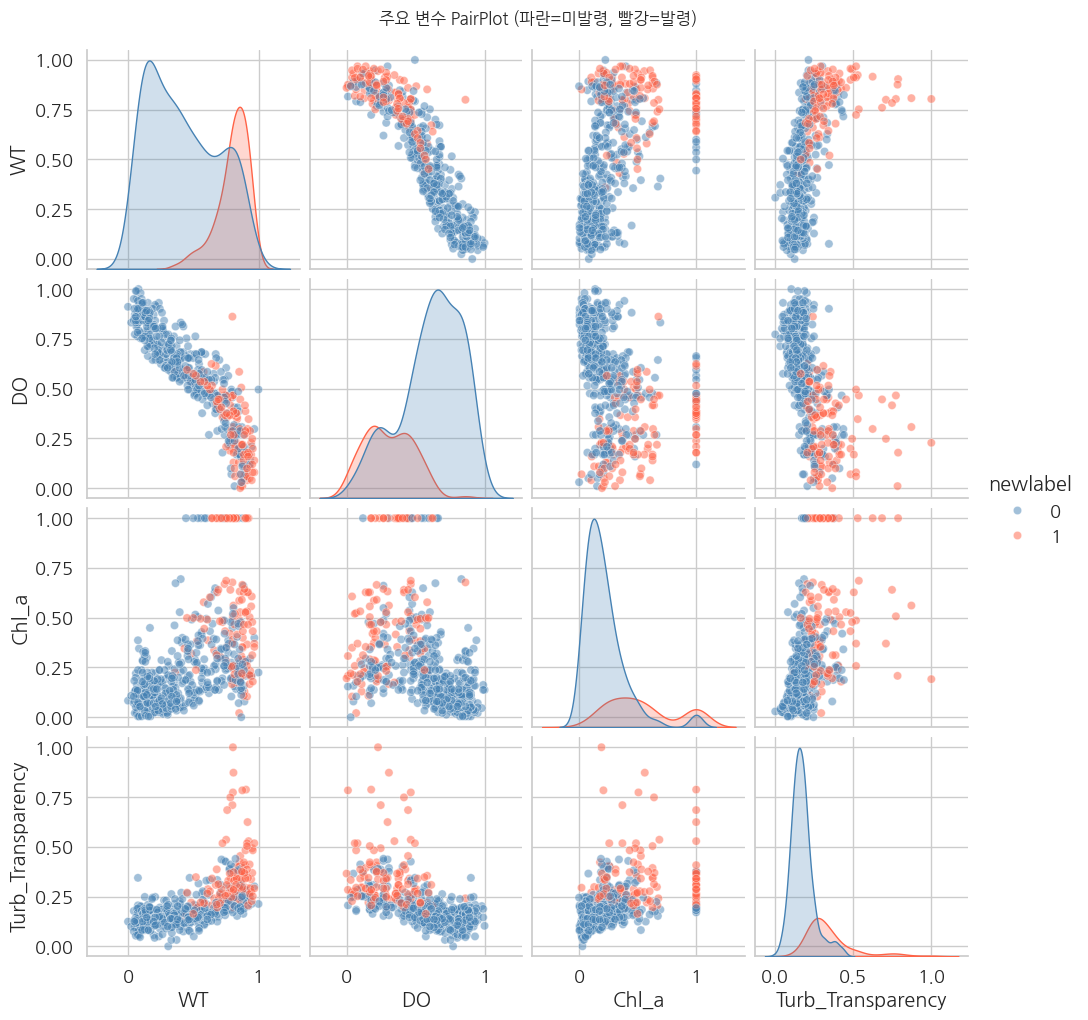

In [38]:
# 16. PairGrid (변수 간 상관성 & 발령 구분)
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# ★ 그래프 직전에 폰트 강제 적용
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

pairplot_cols = ['WT', 'DO', 'Chl_a', 'Turb_Transparency', 'newlabel']
pairplot_cols = [c for c in pairplot_cols if c in df_norm.columns]

pp = sns.pairplot(df_norm[pairplot_cols], hue='newlabel',
                  plot_kws={'alpha': 0.5},
                  palette={0: 'steelblue', 1: 'tomato'})
pp.fig.suptitle('주요 변수 PairPlot (파란=미발령, 빨강=발령)', y=1.02, fontsize=12)
plt.show()
pp.fig.savefig(f'{OUTPUT_DIR}/07_pairplot.png', dpi=120, bbox_inches='tight')
plt.close()

In [39]:
# 17. 결과 요약
print("\n" + "="*60)
print("최종 결과 요약")
print("="*60)
print(f"  데이터: 대청호 추동 지점  ({df.shape[0]}개 주간 관측값)")
print(f"  특성 ({len(FEATURE_COLS)}개): {FEATURE_COLS}")
print(f"  타겟: 이진 분류 (0=미발령, 1=관심+경계+대발생)")
print(f"  모델: XGBClassifier (GridSearchCV + StratifiedKFold-{NUM_FOLDS})")
print(f"  최적 파라미터: {grid_search.best_params_}")
print(f"  교차검증 정확도: {grid_search.best_score_:.4f}")
print(f"  테스트 정확도:   {accuracy:.4f}")
print(f"  중요 특성 Top3: {fi_df.sort_values('Importance',ascending=False)['Feature'].head(3).tolist()}")
print("\n  생성된 파일:")
for fn in sorted(os.listdir(OUTPUT_DIR)):
    if fn.endswith('.png') or fn.endswith('.py'):
        print(f"    {fn}")


최종 결과 요약
  데이터: 대청호 추동 지점  (515개 주간 관측값)
  특성 (23개): ['WT', 'DO', 'Chl_a', 'Rain', 'Total_Discharge', 'Turb_Transparency', 'TN', 'TP', 'COD', 'EC', 'Chl_a_lag1', 'Chl_a_lag2', 'newlabel_lag1', 'newlabel_lag2', 'WT_lag1', 'Turb_T_lag1', 'Chl_a_ma3', 'Chl_a_diff', 'WT_diff', 'month_sin', 'month_cos', 'Rain_ma4', 'Sun_ma3']
  타겟: 이진 분류 (0=미발령, 1=관심+경계+대발생)
  모델: XGBClassifier (GridSearchCV + StratifiedKFold-5)
  최적 파라미터: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0, 'subsample': 0.8}
  교차검증 정확도: 0.9739
  테스트 정확도:   0.9320
  중요 특성 Top3: ['month_sin', 'WT_lag1', 'newlabel_lag1']

  생성된 파일:
    01_timeseries.png
    02_outlier_before.png
    03_correlation_heatmap.png
    04_scatter.png
    05_confusion_matrix.png
    06_feature_importance.png
    07_pairplot.png
